# 08 Computational Method Comparison

## Benchmarking clustering strategies in TNBC single-cell RNA-seq

### Research question
How do different clustering strategies perform in recovering biologically annotated cell populations from TNBC single-cell RNA-seq data?

### Objectives
- Compare centroid-based and graph-based clustering approaches.
- Evaluate clustering performance using biological cell-type annotations.
- Quantitatively assess clustering agreement using ARI and NMI.
- Examine cluster separation using silhouette scores.
- Interpret why different algorithms perform differently on single-cell transcriptomic data.

### Methods compared
1. K-means clustering
2. Leiden graph-based clustering

### Dataset
TNBC single-cell RNA-seq dataset CID4465 used throughout Project 02.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

print("Scanpy version:", sc.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

print("\nImports successful.")

Scanpy version: 1.12.4
Pandas version: 2.3.3
NumPy version: 2.5.1

Imports successful.


/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_1781/1589713607.py:13: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy version:", sc.__version__)


In [2]:
adata = sc.read_h5ad("../data/processed/CID4465_processed.h5ad")

print("AnnData shape:", adata.shape)

print("\nAvailable obs columns:")
print(adata.obs.columns.tolist())

print("\nAvailable obsm keys:")
print(list(adata.obsm.keys()))

print("\nAvailable uns keys:")
print(list(adata.uns.keys()))

AnnData shape: (1534, 13514)

Available obs columns:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype']

Available obsm keys:
['X_umap']

Available uns keys:
['hvg', 'log1p']


In [3]:
print("adata.X type:", type(adata.X))
print("adata.X shape:", adata.X.shape)

print("\nExpression range:")
print("Min:", adata.X.min())
print("Max:", adata.X.max())

print("\nRaw available:", adata.raw is not None)

print("\nHVG information:")
print(adata.uns.get("hvg", "No HVG info found"))

print("\nCurrent Leiden cluster counts:")
print(adata.obs["leiden"].value_counts().sort_index())

print("\nCell type counts:")
print(adata.obs["celltype_major"].value_counts())

adata.X type: <class 'scipy.sparse._csr.csr_matrix'>
adata.X shape: (1534, 13514)

Expression range:
Min: 0.0
Max: 9.024438

Raw available: False

HVG information:
{'flavor': 'seurat'}

Current Leiden cluster counts:
leiden
0    287
1     71
2    148
3    226
4    246
5    125
6     57
7     82
8    116
9    176
Name: count, dtype: int64

Cell type counts:
celltype_major
CAFs                 376
PVL                  314
Endothelial          285
Myeloid              178
T-cells              116
Cancer Epithelial    113
Plasmablasts         110
B-cells               33
Normal Epithelial      9
Name: count, dtype: int64


In [4]:
print("Available var columns:")
print(adata.var.columns.tolist())

if "highly_variable" in adata.var.columns:
    print("\nNumber of stored HVGs:")
    print(adata.var["highly_variable"].sum())
else:
    print("\nNo stored highly_variable column found.")

Available var columns:
['mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm']

Number of stored HVGs:
2000


In [5]:
adata_bench = adata[:, adata.var["highly_variable"]].copy()

print("Benchmarking dataset shape:", adata_bench.shape)
print("Number of cells:", adata_bench.n_obs)
print("Number of HVGs:", adata_bench.n_vars)

Benchmarking dataset shape: (1534, 2000)
Number of cells: 1534
Number of HVGs: 2000


In [6]:
sc.pp.scale(adata_bench, max_value=10)
sc.tl.pca(adata_bench, n_comps=50, svd_solver="arpack")

print("PCA shape:", adata_bench.obsm["X_pca"].shape)

explained = adata_bench.uns["pca"]["variance_ratio"][:10] * 100

print("\nExplained variance of first 10 PCs (%):")
for i, value in enumerate(explained, start=1):
    print(f"PC{i}: {value:.2f}%")

print(f"\nCumulative variance (PC1-10): {explained.sum():.2f}%")

/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PCA shape: (1534, 50)

Explained variance of first 10 PCs (%):
PC1: 1.65%
PC2: 1.16%
PC3: 0.96%
PC4: 0.89%
PC5: 0.64%
PC6: 0.57%
PC7: 0.54%
PC8: 0.42%
PC9: 0.34%
PC10: 0.32%

Cumulative variance (PC1-10): 7.49%


In [7]:
# K-means clustering on the shared PCA representation

X_pca = adata_bench.obsm["X_pca"]

kmeans = KMeans(
    n_clusters=9,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_pca)

adata_bench.obs["kmeans"] = kmeans_labels.astype(str)

print("K-means cluster counts:")
print(
    adata_bench.obs["kmeans"]
    .value_counts()
    .sort_index()
)

K-means cluster counts:
kmeans
0    116
1    243
2    174
3    284
4    242
5    141
6     87
7    125
8    122
Name: count, dtype: int64


In [8]:
# Build a k-nearest-neighbour graph using the same PCA representation

sc.pp.neighbors(
    adata_bench,
    n_neighbors=15,
    n_pcs=50,
    use_rep="X_pca"
)

# Leiden clustering
sc.tl.leiden(
    adata_bench,
    resolution=0.5,
    key_added="leiden_bench",
    random_state=42
)

print("Leiden cluster counts:")
print(
    adata_bench.obs["leiden_bench"]
    .value_counts()
    .sort_index()
)

print("\nNumber of Leiden clusters:")
print(adata_bench.obs["leiden_bench"].nunique())

/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_1781/1000681491.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


Leiden cluster counts:
leiden_bench
0    382
1    304
2    283
3    186
4    174
5    122
6     83
Name: count, dtype: int64

Number of Leiden clusters:
7


In [9]:
# Biological reference labels
reference = adata_bench.obs["celltype_major"].astype(str)

# Predicted clustering labels
kmeans_pred = adata_bench.obs["kmeans"].astype(str)
leiden_pred = adata_bench.obs["leiden_bench"].astype(str)

# Adjusted Rand Index
ari_kmeans = adjusted_rand_score(reference, kmeans_pred)
ari_leiden = adjusted_rand_score(reference, leiden_pred)

# Normalized Mutual Information
nmi_kmeans = normalized_mutual_info_score(reference, kmeans_pred)
nmi_leiden = normalized_mutual_info_score(reference, leiden_pred)

print("=== Clustering agreement with biological annotations ===")

print("\nK-means:")
print(f"ARI: {ari_kmeans:.4f}")
print(f"NMI: {nmi_kmeans:.4f}")

print("\nLeiden:")
print(f"ARI: {ari_leiden:.4f}")
print(f"NMI: {nmi_leiden:.4f}")

=== Clustering agreement with biological annotations ===

K-means:
ARI: 0.7718
NMI: 0.8655

Leiden:
ARI: 0.9087
NMI: 0.8901


In [10]:
# Cluster composition tables

kmeans_table = pd.crosstab(
    adata_bench.obs["kmeans"],
    adata_bench.obs["celltype_major"]
)

leiden_table = pd.crosstab(
    adata_bench.obs["leiden_bench"],
    adata_bench.obs["celltype_major"]
)

print("=== K-means cluster composition ===")
print(kmeans_table)

print("\n=== Leiden cluster composition ===")
print(leiden_table)

=== K-means cluster composition ===
celltype_major  B-cells  CAFs  Cancer Epithelial  Endothelial  Myeloid  \
kmeans                                                                   
0                     1     0                  0            0        0   
1                     0   241                  0            0        0   
2                     0     0                  0            0      174   
3                     0     0                  0          283        1   
4                     0    15                  0            1        0   
5                    29     0                  0            0        3   
6                     0     1                  0            1        0   
7                     3     0                113            0        0   
8                     0   119                  0            0        0   

celltype_major  Normal Epithelial  PVL  Plasmablasts  T-cells  
kmeans                                                         
0                    

In [11]:
def cluster_purity(cluster_labels, reference_labels):
    table = pd.crosstab(cluster_labels, reference_labels)
    dominant_counts = table.max(axis=1)
    purity = dominant_counts.sum() / table.values.sum()
    return purity

kmeans_purity = cluster_purity(
    adata_bench.obs["kmeans"],
    adata_bench.obs["celltype_major"]
)

leiden_purity = cluster_purity(
    adata_bench.obs["leiden_bench"],
    adata_bench.obs["celltype_major"]
)

print("=== Cluster purity ===")
print(f"K-means purity: {kmeans_purity:.4f}")
print(f"Leiden purity:   {leiden_purity:.4f}")

=== Cluster purity ===
K-means purity: 0.9531
Leiden purity:   0.9296


In [12]:
comparison_df = pd.DataFrame({
    "Method": ["K-means", "Leiden"],
    "Number_of_clusters": [
        adata_bench.obs["kmeans"].nunique(),
        adata_bench.obs["leiden_bench"].nunique()
    ],
    "ARI": [ari_kmeans, ari_leiden],
    "NMI": [nmi_kmeans, nmi_leiden],
    "Purity": [kmeans_purity, leiden_purity]
})

comparison_df

,Method,Number_of_clusters,ARI,NMI,Purity
0,K-means,9,0.771804,0.865539,0.953064
1,Leiden,7,0.908679,0.890147,0.929596


In [13]:
comparison_df.to_csv(
    "../results/08_clustering_method_comparison.csv",
    index=False
)

print("Saved: ../results/08_clustering_method_comparison.csv")

Saved: ../results/08_clustering_method_comparison.csv


In [14]:
# Evaluate geometric cluster separation in PCA space

silhouette_kmeans = silhouette_score(
    X_pca,
    adata_bench.obs["kmeans"]
)

silhouette_leiden = silhouette_score(
    X_pca,
    adata_bench.obs["leiden_bench"]
)

print("=== Silhouette scores ===")
print(f"K-means: {silhouette_kmeans:.4f}")
print(f"Leiden:   {silhouette_leiden:.4f}")

=== Silhouette scores ===
K-means: 0.0740
Leiden:   0.0716


In [15]:
comparison_df["Silhouette"] = [
    silhouette_kmeans,
    silhouette_leiden
]

comparison_df

,Method,Number_of_clusters,ARI,NMI,Purity,Silhouette
0,K-means,9,0.771804,0.865539,0.953064,0.073979
1,Leiden,7,0.908679,0.890147,0.929596,0.071632


In [16]:
comparison_df.to_csv(
    "../results/08_clustering_method_comparison.csv",
    index=False
)

print("Updated: ../results/08_clustering_method_comparison.csv")

Updated: ../results/08_clustering_method_comparison.csv


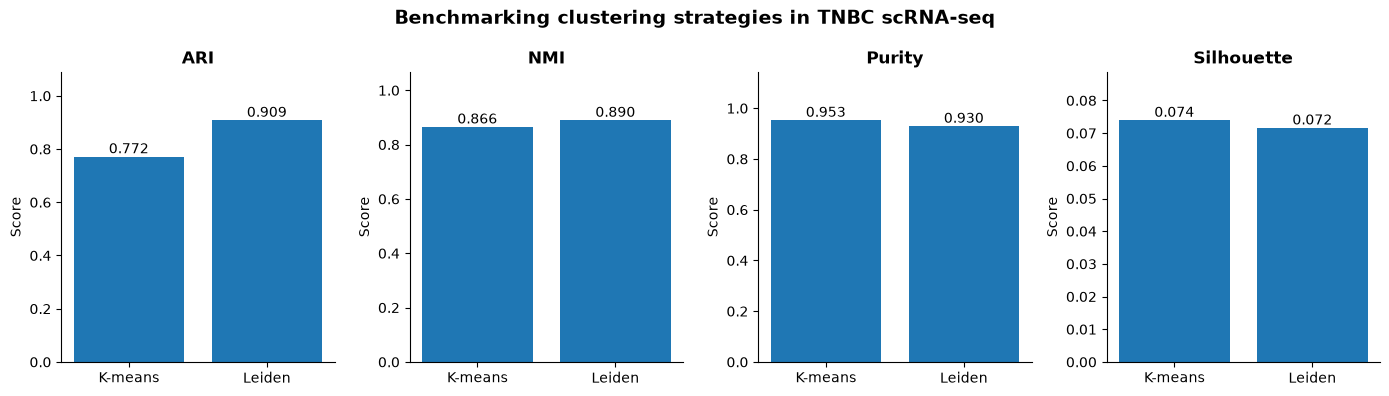

In [17]:
# Visualise quantitative benchmarking metrics

metrics = ["ARI", "NMI", "Purity", "Silhouette"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, metric in zip(axes, metrics):
    values = comparison_df.set_index("Method")[metric]

    bars = ax.bar(
        values.index,
        values.values
    )

    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, max(values.values) * 1.20)

    for bar, value in zip(bars, values.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}",
            ha="center",
            va="bottom"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Benchmarking clustering strategies in TNBC scRNA-seq",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../figures/08_clustering_method_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# Compute UMAP from the shared benchmarking neighbour graph

sc.tl.umap(
    adata_bench,
    random_state=42
)

print("UMAP shape:", adata_bench.obsm["X_umap"].shape)

UMAP shape: (1534, 2)


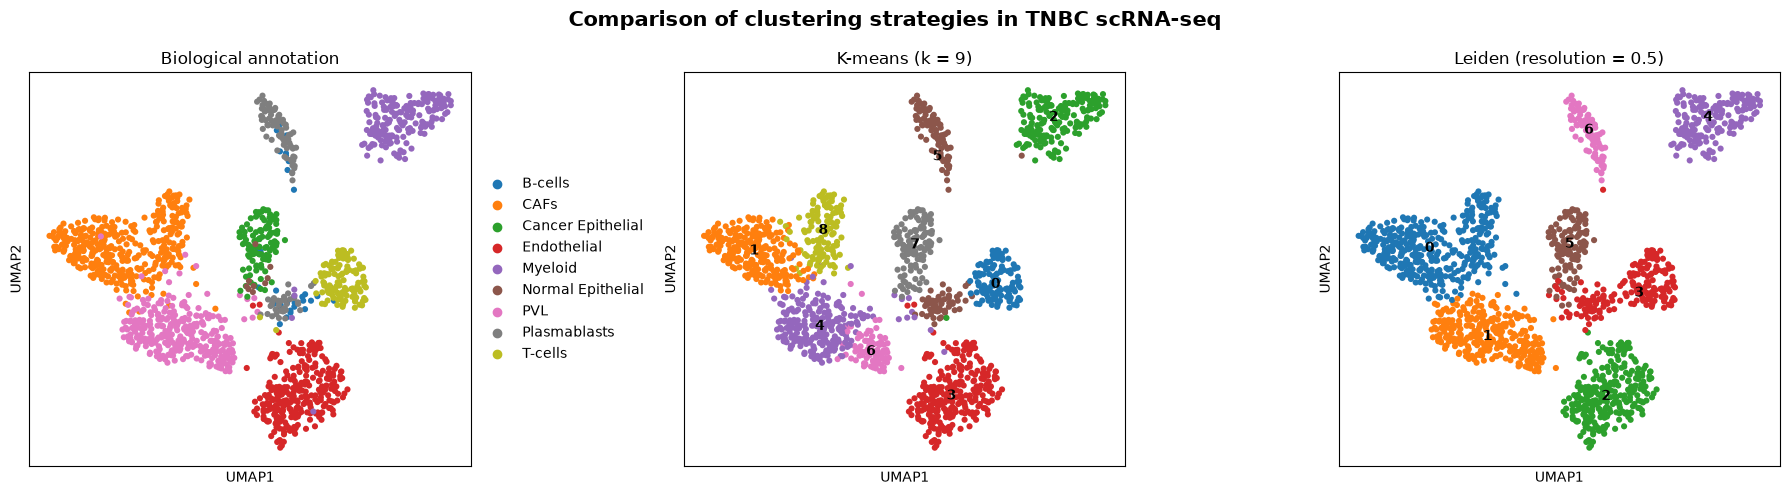

In [19]:
# Compare biological annotations with K-means and Leiden clustering

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.umap(
    adata_bench,
    color="celltype_major",
    ax=axes[0],
    show=False,
    title="Biological annotation",
    legend_loc="right margin"
)

sc.pl.umap(
    adata_bench,
    color="kmeans",
    ax=axes[1],
    show=False,
    title="K-means (k = 9)",
    legend_loc="on data"
)

sc.pl.umap(
    adata_bench,
    color="leiden_bench",
    ax=axes[2],
    show=False,
    title="Leiden (resolution = 0.5)",
    legend_loc="on data"
)

fig.suptitle(
    "Comparison of clustering strategies in TNBC scRNA-seq",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../figures/08_clustering_method_umap_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Leiden resolution sensitivity analysis

resolutions = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]

resolution_results = []

for res in resolutions:
    key = f"leiden_res_{res}"

    sc.tl.leiden(
        adata_bench,
        resolution=res,
        key_added=key,
        random_state=42
    )

    labels = adata_bench.obs[key].astype(str)

    n_clusters = labels.nunique()

    ari = adjusted_rand_score(
        reference,
        labels
    )

    nmi = normalized_mutual_info_score(
        reference,
        labels
    )

    purity = cluster_purity(
        labels,
        reference
    )

    silhouette = silhouette_score(
        X_pca,
        labels
    )

    resolution_results.append({
        "Resolution": res,
        "Number_of_clusters": n_clusters,
        "ARI": ari,
        "NMI": nmi,
        "Purity": purity,
        "Silhouette": silhouette
    })

resolution_df = pd.DataFrame(resolution_results)

resolution_df

/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_1781/613067560.py:10: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(
/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_1781/613067560.py:10: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leid

,Resolution,Number_of_clusters,ARI,NMI,Purity,Silhouette
0,0.2,6,0.848111,0.856473,0.856584,0.052319
1,0.3,7,0.908679,0.890147,0.929596,0.071632
2,0.4,7,0.908679,0.890147,0.929596,0.071632
3,0.5,7,0.908679,0.890147,0.929596,0.071632
4,0.6,8,0.794967,0.840982,0.922425,0.081123
5,0.8,8,0.788040,0.835396,0.919817,0.080783
6,1.0,9,0.792262,0.842311,0.925684,0.084499


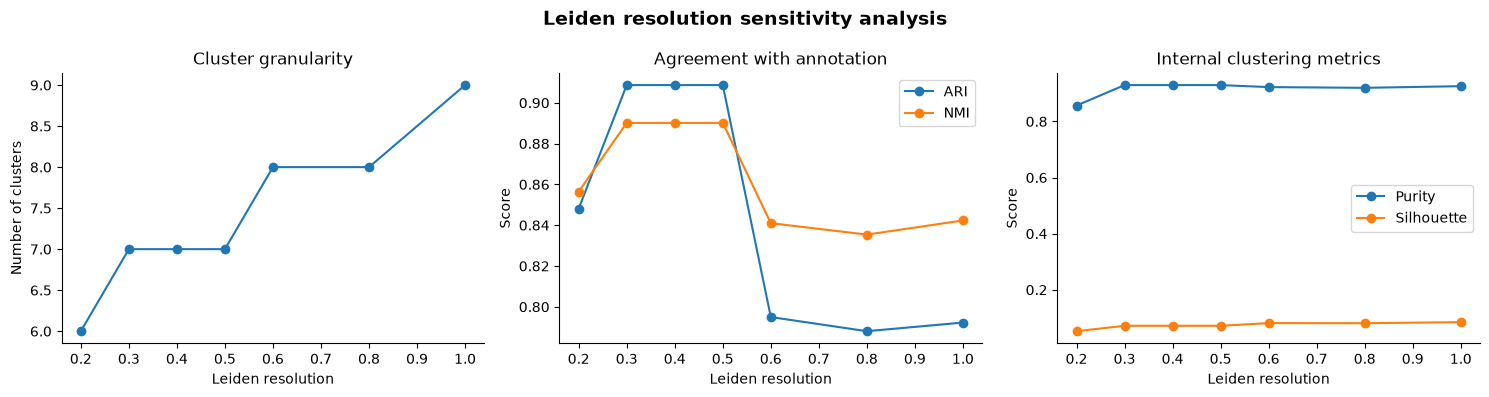

In [21]:
# Visualise Leiden resolution sensitivity

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Number of clusters
axes[0].plot(
    resolution_df["Resolution"],
    resolution_df["Number_of_clusters"],
    marker="o"
)
axes[0].set_xlabel("Leiden resolution")
axes[0].set_ylabel("Number of clusters")
axes[0].set_title("Cluster granularity")

# Biological agreement
axes[1].plot(
    resolution_df["Resolution"],
    resolution_df["ARI"],
    marker="o",
    label="ARI"
)
axes[1].plot(
    resolution_df["Resolution"],
    resolution_df["NMI"],
    marker="o",
    label="NMI"
)
axes[1].set_xlabel("Leiden resolution")
axes[1].set_ylabel("Score")
axes[1].set_title("Agreement with annotation")
axes[1].legend()

# Purity and silhouette
axes[2].plot(
    resolution_df["Resolution"],
    resolution_df["Purity"],
    marker="o",
    label="Purity"
)
axes[2].plot(
    resolution_df["Resolution"],
    resolution_df["Silhouette"],
    marker="o",
    label="Silhouette"
)
axes[2].set_xlabel("Leiden resolution")
axes[2].set_ylabel("Score")
axes[2].set_title("Internal clustering metrics")
axes[2].legend()

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Leiden resolution sensitivity analysis",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../figures/08_leiden_resolution_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
resolution_df.to_csv(
    "../results/08_leiden_resolution_sensitivity.csv",
    index=False
)

print("Saved resolution sensitivity results.")

Saved resolution sensitivity results.


## Final interpretation

This analysis benchmarked centroid-based K-means clustering against graph-based Leiden clustering using the same 50-dimensional PCA representation of 2,000 highly variable genes from 1,534 TNBC single cells.

### Quantitative comparison

K-means produced nine clusters and achieved an ARI of 0.772 and NMI of 0.866 relative to the biological cell-type annotations. Leiden clustering at resolution 0.5 produced seven clusters but showed substantially stronger agreement with the reference annotations, with an ARI of 0.909 and NMI of 0.890.

Interestingly, K-means achieved slightly higher cluster purity (0.953 vs 0.930) and silhouette score (0.074 vs 0.072). Inspection of cluster composition showed that K-means split several biological populations, particularly CAFs and PVL cells, across multiple clusters. This illustrates an important limitation of purity as a standalone evaluation metric: over-splitting a biological population can generate individually pure clusters without improving correspondence to the underlying biological annotation.

In contrast, Leiden recovered several major populations with high consistency, including CAFs, PVL, endothelial, myeloid and cancer epithelial cells. Some closely related lymphoid populations were merged, explaining why the seven Leiden clusters did not correspond one-to-one with the nine reference cell types.

### Resolution sensitivity

Leiden resolution sensitivity analysis showed that resolutions 0.3–0.5 generated the same stable seven-cluster solution and achieved the highest agreement with biological annotations (ARI = 0.909; NMI = 0.890). Increasing the resolution to 0.6–1.0 increased clustering granularity to eight or nine clusters but reduced ARI and NMI, indicating that a larger number of clusters did not necessarily improve biological recovery.

### Computational interpretation

The comparison highlights fundamental differences between the two clustering strategies. K-means partitions cells according to distances from predefined centroids and requires the number of clusters to be specified in advance. These assumptions can be restrictive for heterogeneous single-cell transcriptomic data, where populations may have irregular geometry and continuous transcriptional relationships.

Leiden instead identifies communities within a k-nearest-neighbour graph constructed from the PCA representation, allowing clustering to reflect local neighbourhood structure. In this TNBC dataset, this graph-based approach provided stronger overall correspondence with biological cell identities.

Overall, these results demonstrate that clustering performance should not be evaluated using a single metric or cluster number alone. Combining external agreement metrics, internal clustering metrics, cluster composition and parameter sensitivity provides a more informative assessment of computational methods for single-cell transcriptomics.

In [23]:
print("=== FINAL COMPUTATIONAL METHOD BENCHMARK QC ===")

print(f"Cells analysed: {adata_bench.n_obs}")
print(f"HVGs used: {adata_bench.n_vars}")
print(f"PCA components: {adata_bench.obsm['X_pca'].shape[1]}")

print("\nK-means:")
print(f"Clusters: {adata_bench.obs['kmeans'].nunique()}")
print(f"ARI: {ari_kmeans:.4f}")
print(f"NMI: {nmi_kmeans:.4f}")
print(f"Purity: {kmeans_purity:.4f}")
print(f"Silhouette: {silhouette_kmeans:.4f}")

print("\nLeiden (resolution = 0.5):")
print(f"Clusters: {adata_bench.obs['leiden_bench'].nunique()}")
print(f"ARI: {ari_leiden:.4f}")
print(f"NMI: {nmi_leiden:.4f}")
print(f"Purity: {leiden_purity:.4f}")
print(f"Silhouette: {silhouette_leiden:.4f}")

best_ari_row = resolution_df.loc[resolution_df["ARI"].idxmax()]

print("\nResolution sensitivity:")
print(
    "Highest ARI:",
    f"{best_ari_row['ARI']:.4f}",
    "at resolution",
    best_ari_row["Resolution"]
)

print("\nOutput files:")
print("../results/08_clustering_method_comparison.csv")
print("../results/08_leiden_resolution_sensitivity.csv")
print("../figures/08_clustering_method_benchmark.png")
print("../figures/08_clustering_method_umap_comparison.png")
print("../figures/08_leiden_resolution_sensitivity.png")

=== FINAL COMPUTATIONAL METHOD BENCHMARK QC ===
Cells analysed: 1534
HVGs used: 2000
PCA components: 50

K-means:
Clusters: 9
ARI: 0.7718
NMI: 0.8655
Purity: 0.9531
Silhouette: 0.0740

Leiden (resolution = 0.5):
Clusters: 7
ARI: 0.9087
NMI: 0.8901
Purity: 0.9296
Silhouette: 0.0716

Resolution sensitivity:
Highest ARI: 0.9087 at resolution 0.3

Output files:
../results/08_clustering_method_comparison.csv
../results/08_leiden_resolution_sensitivity.csv
../figures/08_clustering_method_benchmark.png
../figures/08_clustering_method_umap_comparison.png
../figures/08_leiden_resolution_sensitivity.png
